# Logistic Regression Model Notebook

In [1]:
# Import Path for handling file system paths
from pathlib import Path

# Suppress warnings to keep output clean
import warnings
warnings.filterwarnings("ignore")

# Import core libraries for data handling and visualization
import numpy as np                 # Numerical operations
import pandas as pd                # Data manipulation and analysis
import matplotlib.pyplot as plt    # Data visualization

# Import machine learning utilities for model training and evaluation
from sklearn.model_selection import (
    train_test_split,              
    StratifiedKFold,              
    GridSearchCV,                 
    cross_val_score               
)

# Import evaluation metrics
from sklearn.metrics import (
    accuracy_score,               
    balanced_accuracy_score,      
    f1_score,                    
    classification_report,       
    confusion_matrix,             
    ConfusionMatrixDisplay        
)

# Import preprocessing tools
from sklearn.preprocessing import (
    StandardScaler,               
    LabelEncoder                  
)

# Import pipeline for combining preprocessing and model steps
from sklearn.pipeline import Pipeline

# Import Logistic Regression model
from sklearn.linear_model import LogisticRegression

# Import joblib for saving and loading trained models
import joblib

# Set default figure size for plots
plt.rcParams["figure.figsize"] = (8, 5)

# Display all columns in pandas DataFrame (no column truncation)
pd.set_option("display.max_columns", None)

In [2]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# Define possible file path
candidate_paths = [
    Path('/content/drive/MyDrive/sri_lanka_weather_encoded.csv')
]

# Find the first existing file from the candidate paths
data_path = next((p for p in candidate_paths if p.exists()), None)

# Raise an error if dataset is not found and ensures preprocessing step is completed before this notebook
if data_path is None:
    raise FileNotFoundError(
        "Processed dataset not found. Run 01_data_preprocessing.ipynb first."
    )

# Load the dataset into a pandas DataFrame
df = pd.read_csv(data_path)

# Display basic dataset information
print("Loaded file:", data_path)  
print("Shape:", df.shape)     

# Display first few rows for quick inspection
display(df.head())

Loaded file: /content/drive/MyDrive/sri_lanka_weather_encoded.csv
Shape: (147480, 56)


,weathercode,temperature_2m_max,temperature_2m_min,temperature_2m_mean,apparent_temperature_max,apparent_temperature_min,apparent_temperature_mean,shortwave_radiation_sum,precipitation_hours,windspeed_10m_max,windgusts_10m_max,et0_fao_evapotranspiration,elevation,year,month,day,day_of_week,quarter,is_weekend,day_length_hours,month_sin,month_cos,wind_dir_sin,wind_dir_cos,rainfall_class,rainfall_class_encoded,city_Athurugiriya,city_Badulla,city_Bentota,city_Colombo,city_Galle,city_Gampaha,city_Hambantota,city_Hatton,city_Jaffna,city_Kalmunai,city_Kalutara,city_Kandy,city_Kesbewa,city_Kolonnawa,city_Kurunegala,city_Mabole,city_Maharagama,city_Mannar,city_Matale,city_Matara,city_Moratuwa,city_Mount Lavinia,city_Negombo,city_Oruwala,city_Pothuhera,city_Puttalam,city_Ratnapura,city_Sri Jayewardenepura Kotte,city_Trincomalee,city_Weligama
0,2.0,30.0,22.7,26.1,34.4,25.2,29.2,20.92,0.0,11.7,27.4,4.58,16.0,2010.0,1.0,1.0,4.0,1.0,0.0,11.716667,0.5,0.866025,0.342020,0.939693,No Rain,3,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,51.0,29.9,23.5,26.2,33.8,26.2,29.8,17.71,1.0,13.0,27.0,3.84,16.0,2010.0,1.0,2.0,5.0,1.0,1.0,11.733333,0.5,0.866025,0.406737,0.913545,Light Rain,1,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,51.0,29.5,23.2,26.0,34.3,26.3,29.9,17.76,3.0,12.3,27.4,3.65,16.0,2010.0,1.0,3.0,6.0,1.0,1.0,11.716667,0.5,0.866025,0.275637,0.961262,Light Rain,1,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,2.0,28.9,21.9,25.3,31.6,23.4,27.8,16.50,0.0,17.0,34.6,3.79,16.0,2010.0,1.0,4.0,0.0,1.0,0.0,11.733333,0.5,0.866025,-0.069756,0.997564,No Rain,3,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,1.0,28.1,21.3,24.5,30.1,23.1,26.1,23.61,0.0,18.7,37.1,4.97,16.0,2010.0,1.0,5.0,1.0,1.0,0.0,11.733333,0.5,0.866025,-0.087156,0.996195,No Rain,3,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [5]:
# Define possible target column names
possible_targets = ["rainfall_class_encoded", "rainfall_class"]

# Identify which target column exists in the dataset
target_col = next((c for c in possible_targets if c in df.columns), None)

# Raise error if target column is not found
if target_col is None:
    raise ValueError(
        "Target column not found. Expected 'rainfall_class_encoded' or 'rainfall_class'."
    )

# Initialize class names
class_names = None

# If target is not encoded, apply Label Encoding
if target_col == "rainfall_class":
    le = LabelEncoder()
    
    # Convert categorical labels
    df[target_col] = le.fit_transform(df[target_col])
    
    # Store class names for reference
    class_names = list(le.classes_)
    
    # Display encoding details
    print("Encoded rainfall_class automatically.")
    print("Class mapping:", dict(zip(le.classes_, le.transform(le.classes_))))

# If already encoded, extract unique class values
else:
    class_names = [str(c) for c in sorted(df[target_col].unique())]

# Separate features and target
X = df.drop(columns=[target_col]).copy()
y = df[target_col].copy()

# Convert one-hot encoded boolean columns (True/False) - integers (1/0)
bool_cols = X.select_dtypes(include=["bool"]).columns.tolist()
if bool_cols:
    X[bool_cols] = X[bool_cols].astype(int)
    print("Converted boolean columns to integers:", bool_cols)

# Remove any remaining non-numeric columns
non_numeric = X.select_dtypes(exclude=[np.number]).columns.tolist()
if non_numeric:
    print("Dropping unsupported non-numeric feature columns:", non_numeric)
    X = X.drop(columns=non_numeric)

# Display final feature shape
print("Feature shape:", X.shape)

# Display distribution of target classes
print("\nTarget distribution:")
print(y.value_counts().sort_index())

Converted boolean columns to integers: ['city_Athurugiriya', 'city_Badulla', 'city_Bentota', 'city_Colombo', 'city_Galle', 'city_Gampaha', 'city_Hambantota', 'city_Hatton', 'city_Jaffna', 'city_Kalmunai', 'city_Kalutara', 'city_Kandy', 'city_Kesbewa', 'city_Kolonnawa', 'city_Kurunegala', 'city_Mabole', 'city_Maharagama', 'city_Mannar', 'city_Matale', 'city_Matara', 'city_Moratuwa', 'city_Mount Lavinia', 'city_Negombo', 'city_Oruwala', 'city_Pothuhera', 'city_Puttalam', 'city_Ratnapura', 'city_Sri Jayewardenepura Kotte', 'city_Trincomalee', 'city_Weligama']
Dropping unsupported non-numeric feature columns: ['rainfall_class']
Feature shape: (147480, 54)

Target distribution:
rainfall_class_encoded
0     9349
1    69341
2    42063
3    26727
Name: count, dtype: int64


In [6]:
# Split dataset into training set (80%), testing set (20%) 
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Create a machine learning pipeline
log_reg_pipeline = Pipeline([
    ("scaler", StandardScaler()), 
    ("model", LogisticRegression(
        max_iter=4000,            
        class_weight="balanced",   
        random_state=42
    ))
])

# Train the model using training data
log_reg_pipeline.fit(X_train, y_train)

# Make predictions on test data
y_pred = log_reg_pipeline.predict(X_test)

# Evaluate model performance
print("Train accuracy       :", round(log_reg_pipeline.score(X_train, y_train), 4))  
print("Test accuracy        :", round(accuracy_score(y_test, y_pred), 4))            
print("Balanced accuracy    :", round(balanced_accuracy_score(y_test, y_pred), 4))  
print("Macro F1 score       :", round(f1_score(y_test, y_pred, average="macro"), 4))

# Print detailed classification metrics
print("\nClassification Report:")
print(classification_report(y_test,y_pred,target_names=[str(c) for c in class_names]))

Train accuracy       : 0.8973
Test accuracy        : 0.8974
Balanced accuracy    : 0.9007
Macro F1 score       : 0.8623

Classification Report:
              precision    recall  f1-score   support

           0       0.57      0.89      0.69      1870
           1       0.97      0.92      0.94     13868
           2       0.84      0.80      0.82      8413
           3       1.00      1.00      1.00      5345

    accuracy                           0.90     29496
   macro avg       0.84      0.90      0.86     29496
weighted avg       0.91      0.90      0.90     29496



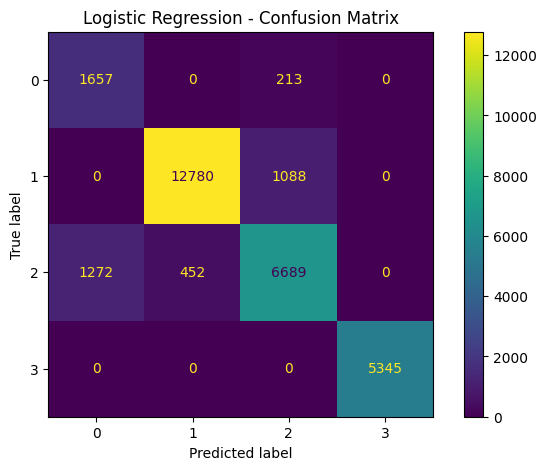

In [7]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot()
plt.title("Logistic Regression - Confusion Matrix")
plt.show()


In [8]:
# cross-validation

# Ensures each fold maintains the same class distribution as the dataset
cv = StratifiedKFold(
    n_splits=5,       
    shuffle=True,      
    random_state=42    
)

# Perform cross-validation using different evaluation metrics

# Accuracy: overall correctness
cv_accuracy = cross_val_score(
    log_reg_pipeline, X, y,
    cv=cv,
    scoring="accuracy"
)

# Balanced accuracy: useful for imbalanced datasets
cv_balanced = cross_val_score(
    log_reg_pipeline, X, y,
    cv=cv,
    scoring="balanced_accuracy"
)

# Macro F1 score: average F1 across all classes (treats all classes equally)
cv_f1_macro = cross_val_score(
    log_reg_pipeline, X, y,
    cv=cv,
    scoring="f1_macro"
)

# Display cross-validation results
print("CV accuracy scores        :", np.round(cv_accuracy, 4))          
print("Mean CV accuracy          :", round(cv_accuracy.mean(), 4))   
print("Mean CV balanced accuracy :", round(cv_balanced.mean(), 4)) 
print("Mean CV macro F1          :", round(cv_f1_macro.mean(), 4))


CV accuracy scores        : [0.8985 0.8962 0.893  0.897  0.8997]
Mean CV accuracy          : 0.8969
Mean CV balanced accuracy : 0.9
Mean CV macro F1          : 0.8612


In [9]:
# Define hyperparameter search space for Logistic Regression

param_grid = [
    {
        "model__solver": ["lbfgs"],          
        "model__C": [0.01, 0.1, 1, 5, 10]    
    },
    {
        "model__solver": ["saga"],          
        "model__penalty": ["l1", "l2"],      
        "model__C": [0.01, 0.1, 1, 5]        
    }
]

# Initialize GridSearchCV for hyperparameter tuning
grid = GridSearchCV(
    estimator=log_reg_pipeline,   
    param_grid=param_grid,        
    cv=3,                         
    scoring="f1_macro",           
    n_jobs=-1                     
)

# Train model across all parameter combinations
grid.fit(X_train, y_train)

# Retrieve the best model after tuning
best_log_reg = grid.best_estimator_

# Predict using the tuned model
best_pred = best_log_reg.predict(X_test)

# Display best hyperparameters and performance
print("Best parameters        :", grid.best_params_)             
print("Best CV macro F1       :", round(grid.best_score_, 4))    

# Evaluate tuned model on test set
print("Tuned test accuracy    :", round(accuracy_score(y_test, best_pred), 4))
print("Tuned balanced accuracy:", round(balanced_accuracy_score(y_test, best_pred), 4))
print("Tuned macro F1         :", round(f1_score(y_test, best_pred, average="macro"), 4))

# Detailed classification report after tuning
print("\nTuned Classification Report:")
print(classification_report(
    y_test,
    best_pred,
    target_names=[str(c) for c in class_names]
))

Best parameters        : {'model__C': 5, 'model__penalty': 'l1', 'model__solver': 'saga'}
Best CV macro F1       : 0.8619
Tuned test accuracy    : 0.8976
Tuned balanced accuracy: 0.9
Tuned macro F1         : 0.8621

Tuned Classification Report:
              precision    recall  f1-score   support

           0       0.57      0.88      0.69      1870
           1       0.97      0.92      0.94     13868
           2       0.84      0.79      0.82      8413
           3       1.00      1.00      1.00      5345

    accuracy                           0.90     29496
   macro avg       0.84      0.90      0.86     29496
weighted avg       0.91      0.90      0.90     29496



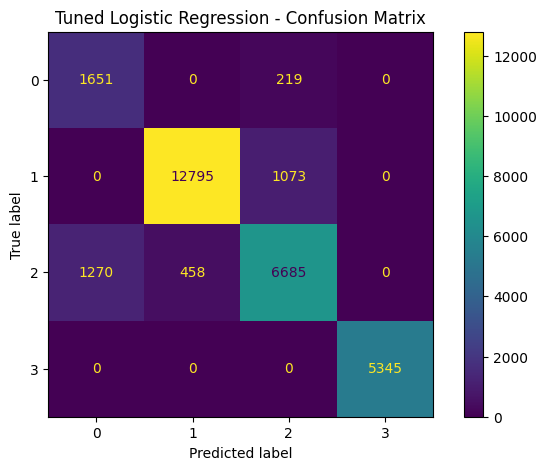

In [10]:
# Tuned confusion matrix
cm_best = confusion_matrix(y_test, best_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_best, display_labels=class_names)
disp.plot()
plt.title("Tuned Logistic Regression - Confusion Matrix")
plt.show()

In [20]:
# Save best model
# Define the path to save the model in Google Drive
model_save_path = Path("/content/drive/MyDrive/models/")
model_save_path.mkdir(parents=True, exist_ok=True)

# Save the best trained logistic regression model
joblib.dump(best_log_reg, model_save_path / "logistic_regression_model.pkl")
print(f"Saved: {model_save_path / 'logistic_regression_model.pkl'}")

Saved: /content/drive/MyDrive/models/logistic_regression_model.pkl


In [12]:
# Predict using tuned model
best_pred = best_log_reg.predict(X_test)

# Evaluation
print("Accuracy:", round(accuracy_score(y_test, best_pred), 4))
print("Balanced accuracy:", round(balanced_accuracy_score(y_test, best_pred), 4))
print("Macro F1:", round(f1_score(y_test, best_pred, average="macro"), 4))

print("\nClassification Report:")
print(classification_report(y_test, best_pred))

Tuned test accuracy    : 0.8976
Tuned balanced accuracy: 0.9
Tuned macro F1         : 0.8621

Tuned Classification Report:
              precision    recall  f1-score   support

           0       0.57      0.88      0.69      1870
           1       0.97      0.92      0.94     13868
           2       0.84      0.79      0.82      8413
           3       1.00      1.00      1.00      5345

    accuracy                           0.90     29496
   macro avg       0.84      0.90      0.86     29496
weighted avg       0.91      0.90      0.90     29496



In [14]:
# Enter your custom values here
# Example values provided. Modify these to your desired inputs.
custom_values = {
    'weathercode': 2.0,
    'temperature_2m_max': 28.0,
    'temperature_2m_min': 20.0,
    'temperature_2m_mean': 24.0,
    'apparent_temperature_max': 30.0,
    'apparent_temperature_min': 22.0,
    'apparent_temperature_mean': 26.0,
    'shortwave_radiation_sum': 20.0,
    'precipitation_hours': 0.0,
    'windspeed_10m_max': 10.0,
    'windgusts_10m_max': 25.0,
    'et0_fao_evapotranspiration': 4.0,
    'elevation': 100.0,
    'year': 2023.0,
    'month': 7.0,
    'day': 15.0,
    'day_of_week': 5.0, # Saturday
    'quarter': 3.0,
    'is_weekend': 1.0,
    'day_length_hours': 12.5,
    'month_sin': 0.866,
    'month_cos': -0.5,
    'wind_dir_sin': 0.707,
    'wind_dir_cos': 0.707,
    'city_Colombo': 1.0
}

# Convert custom_values to a DataFrame, ensuring all model features are present
# Initialize with zeros for all feature columns
input_df = pd.DataFrame(0.0, index=[0], columns=X.columns)

# Update with user-provided custom values
for key, value in custom_values.items():
    if key in input_df.columns:
        input_df[key] = value
    else:
        print(f"Warning: Feature '{key}' from custom_values is not in the model's expected features and will be ignored.")

# Make a prediction using the best trained model
predicted_class_index = best_log_reg.predict(input_df)[0]

# Get the class name if available, otherwise use the numerical index
predicted_class_name = class_names[predicted_class_index] if class_names else predicted_class_index

print(f"Predicted Rainfall Class: {predicted_class_name}")

Predicted Rainfall Class: 3


In [19]:
# Custom values for Moderate Rain
custom_values_moderate_rain = {
    'weathercode': 50.0,  # Rain: moderate intensity
    'temperature_2m_max': 26.0,
    'temperature_2m_min': 21.0,
    'temperature_2m_mean': 23.5,
    'apparent_temperature_max': 28.0,
    'apparent_temperature_min': 20.0,
    'apparent_temperature_mean': 24.0,
    'shortwave_radiation_sum': 10.0, # Lower radiation for cloudy conditions
    'precipitation_hours': 4.0,
    'windspeed_10m_max': 15.0,
    'windgusts_10m_max': 30.0,
    'et0_fao_evapotranspiration': 3.0,
    'elevation': 80.0,
    'year': 2023.0,
    'month': 9.0,
    'day': 5.0,
    'day_of_week': 2.0, # Tuesday
    'quarter': 3.0,
    'is_weekend': 0.0,
    'day_length_hours': 12.0,
    'month_sin': 0.866,
    'month_cos': -0.5,
    'wind_dir_sin': 0.866,
    'wind_dir_cos': 0.5,
    'city_Colombo': 1.0
}

# Convert custom_values_moderate_rain to a DataFrame
input_df_moderate = pd.DataFrame(0.0, index=[0], columns=X.columns)

# Update with provided custom values
for key, value in custom_values_moderate_rain.items():
    if key in input_df_moderate.columns:
        input_df_moderate[key] = value
    else:
        print(f"Warning: Feature '{key}' from custom_values_moderate_rain is not in the model's expected features and will be ignored.")

# Make a prediction using the best trained model
predicted_class_index_moderate = best_log_reg.predict(input_df_moderate)[0]

# Get the class name if available
predicted_class_name_moderate = class_names[predicted_class_index_moderate] if class_names else predicted_class_index_moderate

print(f"Predicted Rainfall Class: {predicted_class_name_moderate}")

Predicted Rainfall Class: 1
